## VoltRelay Energy: Network Performance, Service Failures & Retention Diagnostic
### Data Analytics Hackathon — Gradient Learnings

### Business Problem:
*   **Growing pains**: Completed swaps and revenue are up, but service failures, declining new-rider retention, and deteriorating contribution margin per swap are growing even faster.
*   **Decision point**: Leadership needs data-driven insights to decide on critical budget allocations (e.g., more stations, more batteries, network-wide pricing, fleet partner exclusive).

### Approach:
*   **Evidence-based**: This notebook analyzes actual uploaded files, addresses data quality issues, and builds a clean analytical base.
*   **Core Questions**: Answers six key questions (Q1–Q6) to synthesize an evidence-backed view for the budget decision.
*   **Observational Data**: All claims reflect associations/patterns.

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

In [ ]:

import os, re, glob, gzip, warnings, math
from datetime import timedelta

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)

sns.set_theme(style="whitegrid", context="talk")
PALETTE = sns.color_palette("crest", 8)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11


DATA_DIR = "/content/drive/MyDrive/ML_Hack/"
CLEAN_DIR = os.path.join(DATA_DIR, "cleaned")
os.makedirs(CLEAN_DIR, exist_ok=True)

print("Working data directory:", DATA_DIR)
print("Files visible in DATA_DIR:", sorted(os.listdir(DATA_DIR)))
print("Cleaned-output directory:", CLEAN_DIR)


Working data directory: /content/drive/MyDrive/ML_Hack/
Files visible in DATA_DIR: ['cleaned']
Cleaned-output directory: /content/drive/MyDrive/ML_Hack/cleaned


## Cell 3 — File discovery

In [ ]:

EXPECTED = {
    "swap_events":            ["swap_events"],
    "station_hourly_status":  ["station_hourly_status"],
    "stations":                ["stations"],
    "riders":                  ["riders"],
    "batteries":                ["batteries"],
    "support_tickets":          ["support_tickets"],
    "city_daily_context":       ["city_daily_context"],
    "fleet_partners":           ["fleet_partners"],
}

search_dirs = [DATA_DIR, "/content", "/mnt/user-data/uploads", "."]
all_csvish = set()
for d in search_dirs:
    if os.path.isdir(d):
        all_csvish |= set(glob.glob(os.path.join(d, "*.csv")))
        all_csvish |= set(glob.glob(os.path.join(d, "*.csv.gz")))
        all_csvish |= set(glob.glob(os.path.join(d, "*.gz")))

discovered = {}
for key, patterns in EXPECTED.items():
    matches = [p for p in all_csvish if any(pat in os.path.basename(p).lower() for pat in patterns)]
    matches = sorted(matches)
    discovered[key] = matches

print(f"{'table':<24}{'found':<8}{'file(s)'}")
print("-"*100)
for key, matches in discovered.items():
    status = "YES" if matches else "NO"
    files_str = ", ".join(os.path.basename(m) for m in matches) if matches else "(not found)"
    print(f"{key:<24}{status:<8}{files_str}")

SWAP_EVENTS_FILES = discovered["swap_events"]
SWAP_EVENTS_AVAILABLE = len(SWAP_EVENTS_FILES) > 0

if not SWAP_EVENTS_AVAILABLE:
    print("\n" + "!"*78)
    print("! swap_events file NOT FOUND. Q1 (most), Q2 (wait/failure detail), Q5, Q6")
    print("! will be skipped with a clear PENDING marker rather than fabricated.")
    print("! Drop swap_events.csv / .csv.gz into the data folder and re-run to unlock them.")
    print("!"*78)

for key in ["station_hourly_status", "stations", "riders", "batteries","support_tickets", "city_daily_context", "fleet_partners"]:
    assert key in discovered, f"REQUIRED table '{key}' not found."


table                   found   file(s)
----------------------------------------------------------------------------------------------------
swap_events             YES     swap_events.csv, swap_events.csv
station_hourly_status   YES     station_hourly_status.csv, station_hourly_status.csv
stations                YES     stations.csv, stations.csv
riders                  YES     riders.csv, riders.csv
batteries               YES     batteries.csv, batteries.csv
support_tickets         YES     support_tickets.csv, support_tickets.csv
city_daily_context      YES     city_daily_context.csv, city_daily_context.csv
fleet_partners          YES     fleet_partners.csv, fleet_partners.csv


## Cell 4 — Load small/medium datasets

In [ ]:

def read_any(path, **kwargs):
    '''Read a csv or csv.gz transparently.'''
    comp = "gzip" if path.endswith(".gz") else None
    return pd.read_csv(path, compression=comp, **kwargs)

def read_and_concat(paths, **kwargs):
    parts = [read_any(p, **kwargs) for p in paths]
    return pd.concat(parts, ignore_index=True) if len(parts) > 1 else parts[0]

stations   = read_any(discovered["stations"][0])
riders     = read_any(discovered["riders"][0])
batteries  = read_any(discovered["batteries"][0])
tickets    = read_any(discovered["support_tickets"][0], parse_dates=["created_ts"])
city_ctx   = read_any(discovered["city_daily_context"][0], parse_dates=["date"])
partners   = read_any(discovered["fleet_partners"][0])

# station_hourly_status may arrive as one or several part-files (e.g. _1, _2)
station_hourly = read_and_concat(discovered["station_hourly_status"], parse_dates=["hour_start"])

SMALL_TABLES = {
    "stations": stations, "riders": riders, "batteries": batteries,
    "support_tickets": tickets, "city_daily_context": city_ctx,
    "fleet_partners": partners, "station_hourly_status": station_hourly,
}
for name, df in SMALL_TABLES.items():
    print(f"{name:<24} shape={df.shape}")


stations                 shape=(152, 22)
riders                   shape=(20000, 12)
batteries                shape=(6500, 13)
support_tickets          shape=(44000, 12)
city_daily_context       shape=(3282, 12)
fleet_partners           shape=(12, 12)
station_hourly_status    shape=(1528328, 14)


## Cell 5 — Data inventory: schema, dtypes, sample rows

In [ ]:

for name, df in SMALL_TABLES.items():
    print("="*90)
    print(name.upper(), df.shape)
    print("-"*90)
    print(df.dtypes)
    display(df.head(3))


STATIONS (152, 22)
------------------------------------------------------------------------------------------
station_id                        object
city                              object
zone                              object
latitude                         float64
longitude                        float64
location_type                     object
host_type                         object
commissioned_date                 object
decommissioned_date               object
expansion_wave                    object
charger_generation                object
slots_2w                           int64
slots_3w                           int64
inventory_target_2w                int64
inventory_target_3w                int64
monthly_rent_inr                   int64
monthly_maintenance_inr            int64
grid_tariff_inr_kwh              float64
connectivity_tier                 object
firmware_version                  object
firmware_updated_date             object
competitor_within_1_5km_since

,station_id,city,zone,latitude,longitude,location_type,host_type,commissioned_date,decommissioned_date,expansion_wave,charger_generation,slots_2w,slots_3w,inventory_target_2w,inventory_target_3w,monthly_rent_inr,monthly_maintenance_inr,grid_tariff_inr_kwh,connectivity_tier,firmware_version,firmware_updated_date,competitor_within_1_5km_since
0,STN-BLR-001,Bengaluru,BLR-Electronic City,12.926943,77.604655,transit_hub,mall_parking,2023-12-09,NaN,Launch,Gen1,12,6,32,7,23247,5436,9.29,good,v3.2.1,2025-04-14,NaN
1,STN-BLR-002,Bengaluru,BLR-Central,13.149199,77.530565,commercial_hub,kirana,2023-06-20,NaN,Launch,Gen2,16,0,38,0,23201,5249,8.41,poor,v3.2.1,2025-04-14,NaN
2,STN-BLR-003,Bengaluru,BLR-Electronic City,12.917986,77.607560,commercial_hub,fuel_retailer,2023-09-26,NaN,Launch,Gen2,16,0,43,0,10281,4516,8.66,good,v3.2.1,2025-04-14,NaN


RIDERS (20000, 12)
------------------------------------------------------------------------------------------
rider_id          object
partner_id        object
vehicle_class     object
vehicle_model     object
home_zone         object
signup_date       object
signup_channel    object
plan_type         object
declared_shift    object
age_band          object
kyc_verified        bool
home_city         object
dtype: object


,rider_id,partner_id,vehicle_class,vehicle_model,home_zone,signup_date,signup_channel,plan_type,declared_shift,age_band,kyc_verified,home_city
0,RD-1000000,FP-04,3W,Kranti Cargo3,DEL-Noida,2023-03-08,field_agent,partner_billed,night,45+,True,Delhi NCR
1,RD-1000001,FP-05,2W,Volt Cub,MUM-Thane,2023-03-08,partner_onboarding,partner_billed,mixed,35-44,True,Mumbai
2,RD-1000002,FP-06,2W,Torq X1,HYD-West,2023-03-08,partner_onboarding,partner_billed,evening,25-34,False,Hyderabad


BATTERIES (6500, 13)
------------------------------------------------------------------------------------------
battery_id             object
pack_type              object
supplier               object
manufacturing_lot      object
manufacture_date       object
commission_date        object
rated_capacity_kwh    float64
purchase_cost_inr       int64
initial_soh_pct       float64
bms_firmware           object
retired_date           object
retirement_reason      object
current_soh_pct       float64
dtype: object


...

,city,date,max_temp_c,min_temp_c,rainfall_mm,heat_alert,flood_disruption,festival_or_event,is_public_holiday,grid_outage_hours,competitor_promo_active,ecommerce_sale_event
0,Bengaluru,2024-01-01,16.7,6.7,0.0,False,False,NaN,False,0.0,False,False
1,Bengaluru,2024-01-02,17.3,4.6,1.8,False,False,NaN,False,0.2,False,False
2,Bengaluru,2024-01-03,13.9,6.9,0.7,False,False,NaN,False,0.0,False,False


FLEET_PARTNERS (12, 12)
------------------------------------------------------------------------------------------
partner_id                       object
partner_name                     object
partner_segment                  object
vehicle_class                    object
contract_type                    object
contract_start_date              object
discount_pct                    float64
amendment_date                   object
discount_pct_after_amendment    float64
peak_surcharge_billable          object
payment_terms_days                int64
cities_active                    object
dtype: object


,partner_id,partner_name,partner_segment,vehicle_class,contract_type,contract_start_date,discount_pct,amendment_date,discount_pct_after_amendment,peak_surcharge_billable,payment_terms_days,cities_active
0,FP-01,FeastFly,food_delivery,2W,volume_tiered,2023-04-01,10.0,NaN,NaN,Y,30,BLR|DEL|HYD|PUN|MUM|JAI
1,FP-02,ParcelNest,ecom_logistics,2W,pay_per_swap,2023-07-01,15.0,NaN,NaN,Y,30,BLR|DEL|HYD|MUM
2,FP-03,ZipDrop,quick_commerce,2W,volume_tiered,2023-06-01,12.0,2024-11-01,28.0,N,45,BLR|DEL|HYD|PUN|MUM|JAI


STATION_HOURLY_STATUS (1528328, 14)
------------------------------------------------------------------------------------------
station_id                    object
hour_start            datetime64[ns]
charged_2w_avg               float64
charged_2w_min               float64
charged_3w_min               float64
packs_charging               float64
packs_quarantined            float64
chargers_online              float64
ambient_temp_c               float64
cabinet_temp_c               float64
avg_charge_minutes           float64
outage_minutes               float64
grid_kwh                     float64
telemetry_status              object
dtype: object


,station_id,hour_start,charged_2w_avg,charged_2w_min,charged_3w_min,packs_charging,packs_quarantined,chargers_online,ambient_temp_c,cabinet_temp_c,avg_charge_minutes,outage_minutes,grid_kwh,telemetry_status
0,STN-BLR-001,2024-01-01 00:00:00,6.29,6.0,4.0,1.0,0.0,18.0,8.2,13.5,92.6,0.0,1.86,ok
1,STN-BLR-001,2024-01-01 01:00:00,8.10,8.0,4.0,8.0,0.0,18.0,8.2,11.5,88.0,0.0,13.96,ok
2,STN-BLR-001,2024-01-01 02:00:00,10.56,8.0,4.0,5.0,0.0,18.0,8.2,12.9,80.2,0.0,8.27,ok


## Cell 6 — Data-quality checks (missingness, duplicate keys, foreign keys)

In [ ]:

print("### Missing-value profile (columns with >0 missing) ###\n")
for name, df in SMALL_TABLES.items():
    miss = df.isna().sum()
    miss = miss[miss > 0]
    if len(miss):
        print(f"--- {name} ---")
        print((miss.to_frame("n_missing")
               .assign(pct=lambda x: (100*x["n_missing"]/len(df)).round(2))))
        print()

print("### Primary-key duplicate checks ###\n")
pk_checks = {
    "stations": ("station_id", stations),
    "riders": ("rider_id", riders),
    "batteries": ("battery_id", batteries),
    "support_tickets": ("ticket_id", tickets),
}
for name, (key, df) in pk_checks.items():
    dup = df[key].duplicated().sum()
    print(f"{name:<20} key={key:<12} duplicates={dup}")

print("\n### Foreign-key match rates ###\n")
def fk_rate(child, col, parent_ids, label):
    non_null = child[col].dropna()
    if len(non_null) == 0:
        print(f"{label:<45} n/a (all null)")
        return
    matched = non_null.isin(parent_ids).mean() * 100
    print(f"{label:<45} {matched:6.2f}% matched  (n={len(non_null)})")

fk_rate(tickets, "rider_id", set(riders.rider_id), "support_tickets.rider_id -> riders")
fk_rate(tickets, "station_id", set(stations.station_id), "support_tickets.station_id -> stations")
fk_rate(tickets, "battery_id", set(batteries.battery_id), "support_tickets.battery_id -> batteries")
fk_rate(riders, "partner_id", set(partners.partner_id), "riders.partner_id -> fleet_partners")
fk_rate(station_hourly, "station_id", set(stations.station_id), "station_hourly.station_id -> stations")

print("\n### Categorical value inventories (for schema-drift detection) ###\n")
for col in ["expansion_wave","charger_generation","location_type","host_type",
            "connectivity_tier","firmware_version"]:
    print(f"{col:<22}: {sorted(stations[col].dropna().unique())}")
print(f"{'telemetry_status':<22}: {sorted(station_hourly.telemetry_status.dropna().unique())}")
print(f"{'category (tickets)':<22}: {sorted(tickets.category.dropna().unique())}")
print(f"{'resolution_status':<22}: {sorted(tickets.resolution_status.dropna().unique())}")

print("\n### riders.home_city RAW spellings (needs standardization) ###")
print(sorted(riders.home_city.dropna().unique()))

test_stations = stations[stations.station_id.str.startswith("STN-TST")]
print(f"\nTest stations (STN-TST*) found: {len(test_stations)} of {len(stations)} "
      f"({100*len(test_stations)/len(stations):.2f}%) -> {test_stations.station_id.tolist()}")


### Missing-value profile (columns with >0 missing) ###

--- stations ---
                               n_missing    pct
decommissioned_date                  151  99.34
competitor_within_1_5km_since        142  93.42

--- riders ---
                n_missing    pct
partner_id           7628  38.14
declared_shift       3662  18.31
age_band             1547   7.74

--- batteries ---
                   n_missing    pct
retired_date            5062  77.88
retirement_reason       5062  77.88

--- support_tickets ---
                  n_missing    pct
station_id             2227   5.06
battery_id            13235  30.08
resolution_hours       6112  13.89
csat_score            28871  65.62

--- city_daily_context ---
                   n_missing    pct
festival_or_event       3172  96.65

--- fleet_partners ---
                              n_missing    pct
amendment_date                       11  91.67
discount_pct_after_amendment         11  91.67

--- station_hourly_status ---
           


### Cell 7 — Data Cleaning

**Cleaning decisions**

- **Test stations:** Flagged `STN-TST` stations instead of deleting them. They are excluded from network KPIs but kept for auditing and joins.
- **City names:** Standardized 21 different spellings into 6 cities. The original `home_city` column is kept, and `home_city_clean` is used for analysis.
- **Support tickets:** Kept ticket categories unchanged because they are agent-assigned and may not always reflect the actual issue.
- **CSAT:** Missing values were kept as `NaN`. Since missingness is not random, CSAT is reported only for tickets where a score was recorded.
- **Station telemetry:** Hours marked `missing` or `partial` were excluded from rate calculations instead of being treated as zero activity or zero outages.

**Why this matters:**  
These steps prevent data-quality issues from creating misleading conclusions in the analysis.


In [ ]:

cleaning_log = []  # list of dicts

# --- 1. Test stations: flag, don't delete
stations["is_test_station"] = stations.station_id.str.startswith("STN-TST")
n_test = stations.is_test_station.sum()
cleaning_log.append(dict(
    issue="Test stations (STN-TST*)", rows_affected=int(n_test),
    percent_of_rows=round(100*n_test/len(stations), 3),
    action_taken="Flagged with is_test_station; excluded from network KPI aggregates, retained in table",
    reason="Internal test stations produce unrepresentative zero-value transactions"
))

# --- 2. City standardization
CITY_MAP = {
    "blr": "Bengaluru", "bangalore": "Bengaluru", "bengaluru": "Bengaluru",
    "bombay": "Mumbai", "mumbai": "Mumbai", "mum": "Mumbai",
    "delhi": "Delhi NCR", "delhi ncr": "Delhi NCR", "gurgaon": "Delhi NCR", "new delhi": "Delhi NCR",
    "hyd": "Hyderabad", "hyderabad": "Hyderabad",
    "jai": "Jaipur", "jaipur": "Jaipur",
    "pun": "Pune", "pune": "Pune",
}
def clean_city(raw):
    if pd.isna(raw):
        return np.nan
    key = str(raw).strip().lower()
    return CITY_MAP.get(key, raw)  # fall back to raw value if an unseen spelling appears (visible, not silently dropped)

riders["home_city_clean"] = riders.home_city.map(clean_city)
unmapped = sorted(set(riders.home_city_clean.dropna().unique()) - set(stations.city.unique()))
n_recoded = (riders.home_city != riders.home_city_clean).sum()
cleaning_log.append(dict(
    issue="riders.home_city spelling inconsistencies", rows_affected=int(n_recoded),
    percent_of_rows=round(100*n_recoded/len(riders), 3),
    action_taken="Added home_city_clean mapped to the 6 canonical station cities; home_city preserved unchanged",
    reason="21 raw spellings observed for 6 real cities (abbreviations, casing, colloquial names)"
))
print("Riders recoded to canonical city name:", n_recoded, f"({100*n_recoded/len(riders):.1f}%)")
print("Any home_city_clean values NOT in the 6 canonical cities (should be empty):", unmapped)

# --- 3. Support ticket CSAT non-randomness (documented, no destructive change)
csat_missing_resolved = tickets.loc[tickets.resolution_status=="resolved", "csat_score"].isna().mean()
csat_missing_other = tickets.loc[tickets.resolution_status!="resolved", "csat_score"].isna().mean()
cleaning_log.append(dict(
    issue="CSAT missingness is non-random", rows_affected=int(tickets.csat_score.isna().sum()),
    percent_of_rows=round(100*tickets.csat_score.isna().mean(), 2),
    action_taken="Left as NaN (no imputation/deletion); all CSAT averages reported as 'among tickets with recorded CSAT'",
    reason=f"100% missing for unresolved/duplicate tickets vs {100*csat_missing_resolved:.0f}% missing even for resolved tickets -> not missing-at-random"
))

# --- 4. Battery SOH sanity bounds (raw values already look plausible: 55-89%)
soh_out_of_range = batteries[(batteries.current_soh_pct < 0) | (batteries.current_soh_pct > 100)]
cleaning_log.append(dict(
    issue="battery current_soh_pct out-of-[0,100] check", rows_affected=int(len(soh_out_of_range)),
    percent_of_rows=round(100*len(soh_out_of_range)/len(batteries), 3),
    action_taken="None needed" if len(soh_out_of_range)==0 else "Flagged for review",
    reason="Sanity bound check on battery health data"
))

# --- 5. Station telemetry missingness (respected, not zero-filled)
n_missing_tel = (station_hourly.telemetry_status == "missing").sum()
n_partial_tel = (station_hourly.telemetry_status == "partial").sum()
cleaning_log.append(dict(
    issue="station_hourly telemetry_status missing/partial", rows_affected=int(n_missing_tel+n_partial_tel),
    percent_of_rows=round(100*(n_missing_tel+n_partial_tel)/len(station_hourly), 3),
    action_taken="Excluded 'missing' hours from rate denominators; 'partial' hours kept but flagged",
    reason="telemetry_status explicitly distinguishes real zero-activity hours from sensor/reporting gaps"
))

print("\nCleaning steps logged so far:", len(cleaning_log))


Riders recoded to canonical city name: 585 (2.9%)
Any home_city_clean values NOT in the 6 canonical cities (should be empty): []

Cleaning steps logged so far: 5


## Cell 8 — Validation after cleaning

In [ ]:

print("### Post-cleaning validation ###\n")
print("1) riders.home_city_clean fully mapped to 6 canonical cities:",
      set(riders.home_city_clean.dropna().unique()) <= set(stations.city.unique()))
print("2) stations.is_test_station counts:", stations.is_test_station.value_counts().to_dict())
print("3) station_hourly rows by telemetry_status:", station_hourly.telemetry_status.value_counts().to_dict())
print("4) battery current_soh_pct range after check: "
      f"[{batteries.current_soh_pct.min():.1f}, {batteries.current_soh_pct.max():.1f}]  (0 out-of-range rows)")
print("5) support_tickets CSAT coverage: "
      f"{100*tickets.csat_score.notna().mean():.1f}% of all tickets have a recorded CSAT")

cleaning_summary = pd.DataFrame(cleaning_log)
print("\n=== cleaning_summary (so far — swap_events issues appended after its pipeline runs) ===")
display(cleaning_summary)


### Post-cleaning validation ###

1) riders.home_city_clean fully mapped to 6 canonical cities: True
2) stations.is_test_station counts: {False: 150, True: 2}
3) station_hourly rows by telemetry_status: {'ok': 1481550, 'partial': 37434, 'missing': 9342}
4) battery current_soh_pct range after check: [55.4, 88.6]  (0 out-of-range rows)
5) support_tickets CSAT coverage: 34.4% of all tickets have a recorded CSAT

=== cleaning_summary (so far — swap_events issues appended after its pipeline runs) ===


,issue,rows_affected,percent_of_rows,action_taken,reason
0,Test stations (STN-TST*),2,1.316,Flagged with is_test_station; excluded from ne...,Internal test stations produce unrepresentativ...
1,riders.home_city spelling inconsistencies,585,2.925,Added home_city_clean mapped to the 6 canonica...,21 raw spellings observed for 6 real cities (a...
2,CSAT missingness is non-random,28871,65.620,Left as NaN (no imputation/deletion); all CSAT...,100% missing for unresolved/duplicate tickets ...
3,"battery current_soh_pct out-of-[0,100] check",0,0.000,None needed,Sanity bound check on battery health data
4,station_hourly telemetry_status missing/partial,46776,3.061,Excluded 'missing' hours from rate denominator...,telemetry_status explicitly distinguishes real...



### Cell 9 — KPI Definitions

**Contribution Margin Proxy**

`Contribution Margin Proxy = Amount Charged − Electricity Cost`

Where:

`Electricity Cost = Energy Used × Station Grid Tariff`

- Uses the revenue and electricity-cost fields available for each completed swap.
- Monthly rent and maintenance are excluded because they are station-level fixed costs, not per-swap costs.
- Battery purchase/depreciation is also excluded because there is no reliable per-swap depreciation measure.
- Partner discounts are already reflected in `amount_charged_inr`.

**Why this matters:**  
This is a practical **unit-economics proxy**, not a full finance-grade profit measure. It is suitable for comparing margin trends across time and segments.


In [ ]:

def volume_weighted_rate(df, num_col, group_cols, min_n=200):
    '''Rate (mean of a 0/1 or numeric outcome) by group, with sample size, for defensible
    'best/worst segment' comparisons. Groups below min_n are flagged, not silently dropped.'''
    g = df.groupby(group_cols).agg(n=(num_col, "size"), rate=(num_col, "mean")).reset_index()
    g["low_volume"] = g["n"] < min_n
    return g.sort_values("rate", ascending=False)

def pct(n, d):
    return np.nan if d == 0 else 100.0 * n / d

def annotate_bars(ax, fmt="{:.1f}"):
    for p in ax.patches:
        h = p.get_height()
        if pd.notna(h):
            ax.annotate(fmt.format(h), (p.get_x()+p.get_width()/2, h),
                        ha="center", va="bottom", fontsize=9, xytext=(0,2), textcoords="offset points")

print("Helper functions ready: volume_weighted_rate(), pct(), annotate_bars()")
print("Contribution-margin proxy formula documented above; computed later once swap_events loads.")


Helper functions ready: volume_weighted_rate(), pct(), annotate_bars()
Contribution-margin proxy formula documented above; computed later once swap_events loads.



### Cell 10 — `swap_events` Cleaning

- Processed the ~690MB file in chunks to keep Colab memory-safe.
- Fixed timestamp issues, flagged test stations, cleaned invalid SOC/SOH and distance values.
- Removed likely offline retry duplicates while keeping the original records traceable.
- Saved the cleaned data as Parquet so later analysis runs faster without re-reading the raw CSV.


In [ ]:

CLEAN_PARQUET = os.path.join(CLEAN_DIR, "swap_events_clean.parquet")
FIRMWARE_BUG_START = pd.Timestamp("2025-03-10")
FIRMWARE_BUG_END   = pd.Timestamp("2025-04-14 23:59:59")
FIRMWARE_BUG_SHIFT = pd.Timedelta(hours=5, minutes=30)
EXPECTED_START = pd.Timestamp("2024-01-01")
EXPECTED_END   = pd.Timestamp("2025-06-30 23:59:59")
DEDUP_WINDOW   = pd.Timedelta(minutes=5)

swap_cleaning_stats = dict(
    rows_in=0, rows_out=0, test_station_rows=0, firmware_corrected_rows=0,
    near_dup_removed=0, invalid_ts_rows=0, invalid_distance_rows=0,
    soc_soh_clipped=0, soc_soh_negative=0,
)

def clean_swap_chunk(chunk, test_station_ids, firmware_v320_stations):
    global swap_cleaning_stats
    swap_cleaning_stats["rows_in"] += len(chunk)

    # --- schema-adaptive column detection (never assume; only use columns that exist) ---
    cols = set(chunk.columns)
    assert "event_ts" in cols, "swap_events is missing an event_ts column — cannot proceed with temporal cleaning."
    chunk["event_ts"] = pd.to_datetime(chunk["event_ts"], errors="coerce")
    n_bad_ts = chunk["event_ts"].isna().sum()
    swap_cleaning_stats["invalid_ts_rows"] += int(n_bad_ts)

    # test stations
    if "station_id" in cols:
        chunk["is_test_station"] = chunk["station_id"].isin(test_station_ids)
        swap_cleaning_stats["test_station_rows"] += int(chunk["is_test_station"].sum())
    else:
        chunk["is_test_station"] = False

    # firmware timestamp bug correction (idempotent: only ever applied once per row here)
    if "station_firmware" in cols and "station_id" in cols:
        in_bug_window = (chunk["station_firmware"] == "v3.2.0") & \
                         (chunk["station_id"].isin(firmware_v320_stations)) & \
                         chunk["event_ts"].between(FIRMWARE_BUG_START, FIRMWARE_BUG_END)
        chunk["timestamp_corrected"] = in_bug_window
        chunk.loc[in_bug_window, "event_ts"] = chunk.loc[in_bug_window, "event_ts"] + FIRMWARE_BUG_SHIFT
        swap_cleaning_stats["firmware_corrected_rows"] += int(in_bug_window.sum())
    else:
        chunk["timestamp_corrected"] = False

    # SOC/SOH cleaning: keep raw, add *_clean with drift-clip + impossible->NaN
    for c in ["soc_in_pct", "soh_in_pct", "soc_out_pct", "soh_out_pct"]:
        if c in cols:
            raw = chunk[c]
            clean = raw.copy()
            neg_mask = raw < 0
            clip_mask = raw > 100
            clean[neg_mask] = np.nan
            clean[clip_mask] = 100.0
            chunk[c + "_clean"] = clean
            swap_cleaning_stats["soc_soh_clipped"] += int(clip_mask.sum())
            swap_cleaning_stats["soc_soh_negative"] += int(neg_mask.sum())

    # km_since_last_swap: impossible values -> NaN in a cleaned column, raw preserved
    if "km_since_last_swap" in cols:
        raw = chunk["km_since_last_swap"]
        bad = (raw < 0) | (raw > 1000)  # generous ceiling for daily usage; documented assumption
        chunk["km_since_last_swap_clean"] = raw.where(~bad, np.nan)
        swap_cleaning_stats["invalid_distance_rows"] += int(bad.sum())

    return chunk

def dedup_offline_batch(df):
    '''Defensible near-duplicate rule: within offline_batch sync, same rider+station+battery pair
    within a 5-minute window is treated as a retry -> keep first occurrence only.'''
    if "sync_mode" not in df.columns:
        return df, 0
    key_cols = [c for c in ["rider_id","station_id","battery_in_id","battery_out_id"] if c in df.columns]
    if not key_cols:
        return df, 0
    df = df.sort_values("event_ts")
    offline = df[df.sync_mode == "offline_batch"].copy()
    if offline.empty:
        return df, 0
    offline["_grp"] = offline.groupby(key_cols).cumcount()
    offline["_t_prev"] = offline.groupby(key_cols)["event_ts"].diff()
    is_retry = offline["_t_prev"].notna() & (offline["_t_prev"] <= DEDUP_WINDOW)
    drop_idx = offline.index[is_retry]
    removed = len(drop_idx)
    df_clean = df.drop(index=drop_idx)
    return df_clean, removed

USECOLS = [c for c in [
    "event_id","rider_id","station_id","event_ts","event_type","attempt_seq","queue_wait_sec",
    "battery_in_id","battery_out_id","soc_in_pct","soh_in_pct","soc_out_pct","soh_out_pct",
    "km_since_last_swap","tariff_code","list_price_inr","discount_inr","amount_charged_inr",
    "payment_mode","energy_to_recharge_kwh","station_firmware","sync_mode",
] ]  # trimmed to actually-present columns once the header is peeked, below

if SWAP_EVENTS_AVAILABLE:
    se_path = SWAP_EVENTS_FILES[0]
    header_cols = list(read_any(se_path, nrows=0).columns)
    usecols_final = [c for c in USECOLS if c in header_cols]
    missing_expected = [c for c in USECOLS if c not in header_cols]
    if missing_expected:
        print("NOTE: expected columns not found in swap_events (will be skipped, not invented):", missing_expected)

    test_station_ids = set(stations.loc[stations.is_test_station, "station_id"])
    firmware_v320_ids = set(stations.loc[stations.firmware_version == "v3.2.0", "station_id"])

    CHUNK_SIZE = 250_000
    cleaned_chunks = []
    comp = "gzip" if se_path.endswith(".gz") else None
    reader = pd.read_csv(se_path, usecols=usecols_final, chunksize=CHUNK_SIZE, compression=comp)
    for i, chunk in enumerate(reader):
        chunk = clean_swap_chunk(chunk, test_station_ids, firmware_v320_ids)
        cleaned_chunks.append(chunk)
        print(f"  processed chunk {i+1}, rows so far: {swap_cleaning_stats['rows_in']:,}", end="\r")
    swap_events = pd.concat(cleaned_chunks, ignore_index=True)
    del cleaned_chunks

    swap_events, n_dedup_removed = dedup_offline_batch(swap_events)
    swap_cleaning_stats["near_dup_removed"] = n_dedup_removed
    swap_cleaning_stats["rows_out"] = len(swap_events)

    swap_events.to_parquet(CLEAN_PARQUET, index=False)
    print(f"\n\nSaved cleaned swap_events -> {CLEAN_PARQUET}  ({len(swap_events):,} rows)")

    for issue, rows, action, reason in [
        ("Invalid/unparseable event_ts", swap_cleaning_stats["invalid_ts_rows"], "Coerced to NaT, excluded from temporal analysis", "Non-parseable timestamps cannot support temporal analysis"),
        ("Test-station rows (STN-TST*)", swap_cleaning_stats["test_station_rows"], "Flagged is_test_station; excluded from network KPIs", "Internal test stations produce unrepresentative transactions"),
        ("Firmware v3.2.0 timestamp bug (2025-03-10 to 2025-04-14)", swap_cleaning_stats["firmware_corrected_rows"], "Shifted event_ts by +5h30m; flagged timestamp_corrected", "Documented firmware clock bug"),
        ("Offline-batch retry near-duplicates", swap_cleaning_stats["near_dup_removed"], "Removed (kept first occurrence per rider+station+battery within 5-min window)", "Sync retries create duplicate event rows"),
        ("SOC/SOH >100% (sensor drift)", swap_cleaning_stats["soc_soh_clipped"], "Clipped to 100 in *_clean columns; raw preserved", "Sensor calibration drift, not a real >100% state of charge"),
        ("SOC/SOH negative (impossible)", swap_cleaning_stats["soc_soh_negative"], "Set to NaN in *_clean columns; raw preserved", "Physically impossible reading"),
        ("km_since_last_swap out of [0,1000] range", swap_cleaning_stats["invalid_distance_rows"], "Set to NaN in km_since_last_swap_clean; raw preserved", "Negative/implausibly large distance readings"),
    ]:
        cleaning_log.append(dict(issue=issue, rows_affected=int(rows),
                                  percent_of_rows=round(100*rows/max(swap_cleaning_stats['rows_in'],1), 4),
                                  action_taken=action, reason=reason))

    print("\nBefore/after row counts:")
    print(f"  rows_in  = {swap_cleaning_stats['rows_in']:,}")
    print(f"  rows_out = {swap_cleaning_stats['rows_out']:,}  "
          f"(removed {swap_cleaning_stats['rows_in']-swap_cleaning_stats['rows_out']:,} near-duplicates)")
else:
    swap_events = None
    print("PENDING — swap_events not found. Skipping ingestion/cleaning pipeline.")
    print("Upload swap_events.csv (or .csv.gz) and re-run this notebook top-to-bottom to unlock:")
    print("  Q1 (network trends), Q2 wait/failure detail, Q5 (pricing/partner economics), Q6 (retention).")




Saved cleaned swap_events -> /content/drive/MyDrive/ML_Hack/cleaned/swap_events_clean.parquet  (3,877,013 rows)

Before/after row counts:
  rows_in  = 3,877,013
  rows_out = 3,877,013  (removed 0 near-duplicates)


## Cell 11 — Validation of cleaned `swap_events`

In [ ]:

if SWAP_EVENTS_AVAILABLE:
    print("event_id uniqueness:", swap_events["event_id"].is_unique if "event_id" in swap_events else "no event_id column")
    print("event_ts range:", swap_events.event_ts.min(), "to", swap_events.event_ts.max())
    out_of_range = (~swap_events.event_ts.between(EXPECTED_START, EXPECTED_END)).sum()
    print(f"Rows with event_ts outside expected Jan-2024..Jun-2025 window: {out_of_range:,} "
          f"({pct(out_of_range, len(swap_events)):.2f}%) -- reported, not auto-dropped")

    if "station_id" in swap_events.columns:
        fk = swap_events.station_id.isin(stations.station_id).mean()*100
        print(f"station_id FK match to stations: {fk:.2f}%")
    if "rider_id" in swap_events.columns:
        fk = swap_events.rider_id.isin(riders.rider_id).mean()*100
        print(f"rider_id FK match to riders: {fk:.2f}%")
    if "event_type" in swap_events.columns:
        print("\nevent_type distribution:\n", swap_events.event_type.value_counts())
    if "sync_mode" in swap_events.columns:
        print("\nsync_mode distribution:\n", swap_events.sync_mode.value_counts())
    if "station_firmware" in swap_events.columns:
        print("\nstation_firmware distribution:\n", swap_events.station_firmware.value_counts())

    cleaning_summary = pd.DataFrame(cleaning_log)
    print("\n=== FULL cleaning_summary (small tables + swap_events) ===")
    display(cleaning_summary)
else:
    print("PENDING — swap_events not found; nothing to validate yet.")


event_id uniqueness: True
event_ts range: 2024-01-01 00:00:33 to 2025-06-30 23:59:23
Rows with event_ts outside expected Jan-2024..Jun-2025 window: 0 (0.00%) -- reported, not auto-dropped
station_id FK match to stations: 100.00%
rider_id FK match to riders: 100.00%

event_type distribution:
 event_type
swap_completed               3645809
failed_no_charged_battery     134389
abandoned_queue                68533
cancelled_by_rider             16712
failed_system_error            11570
Name: count, dtype: int64

sync_mode distribution:
 sync_mode
realtime         3285899
offline_batch     591114
Name: count, dtype: int64

station_firmware distribution:
 station_firmware
v3.2.1    2315839
v3.2.0    1561174
Name: count, dtype: int64

=== FULL cleaning_summary (small tables + swap_events) ===


,issue,rows_affected,percent_of_rows,action_taken,reason
0,Test stations (STN-TST*),2,1.3160,Flagged with is_test_station; excluded from ne...,Internal test stations produce unrepresentativ...
1,riders.home_city spelling inconsistencies,585,2.9250,Added home_city_clean mapped to the 6 canonica...,21 raw spellings observed for 6 real cities (a...
2,CSAT missingness is non-random,28871,65.6200,Left as NaN (no imputation/deletion); all CSAT...,100% missing for unresolved/duplicate tickets ...
3,"battery current_soh_pct out-of-[0,100] check",0,0.0000,None needed,Sanity bound check on battery health data
4,station_hourly telemetry_status missing/partial,46776,3.0610,Excluded 'missing' hours from rate denominator...,telemetry_status explicitly distinguishes real...
5,Invalid/unparseable event_ts,0,0.0000,"Coerced to NaT, excluded from temporal analysis",Non-parseable timestamps cannot support tempor...
6,Test-station rows (STN-TST*),62031,1.6000,Flagged is_test_station; excluded from network...,Internal test stations produce unrepresentativ...
7,Firmware v3.2.0 timestamp bug (2025-03-10 to 2...,139490,3.5979,Shifted event_ts by +5h30m; flagged timestamp_...,Documented firmware clock bug
8,Offline-batch retry near-duplicates,0,0.0000,Removed (kept first occurrence per rider+stati...,Sync retries create duplicate event rows
9,SOC/SOH >100% (sensor drift),9853,0.2541,Clipped to 100 in *_clean columns; raw preserved,"Sensor calibration drift, not a real >100% sta..."


---
# Q1 — Network performance over time

### Question:
*   How have completed swaps, revenue, failure rate, and contribution margin per swap changed over time?
*   Do these metrics tell a consistent story, or are there conflicting trends?

,total_attempts,completed_swaps,failed_attempts,failure_rate_pct,revenue_inr,avg_margin_per_swap_inr
month,,,,,,
2024-01-01,108278,0.0,0.0,0.0,0.0,0.0
2024-02-01,109271,0.0,0.0,0.0,0.0,0.0
2024-03-01,121487,0.0,0.0,0.0,0.0,0.0
2024-04-01,128991,0.0,0.0,0.0,0.0,0.0
2024-05-01,143189,0.0,0.0,0.0,0.0,0.0
2024-06-01,145880,0.0,0.0,0.0,0.0,0.0
2024-07-01,155343,0.0,0.0,0.0,0.0,0.0
2024-08-01,168900,0.0,0.0,0.0,0.0,0.0
2024-09-01,192479,0.0,0.0,0.0,0.0,0.0


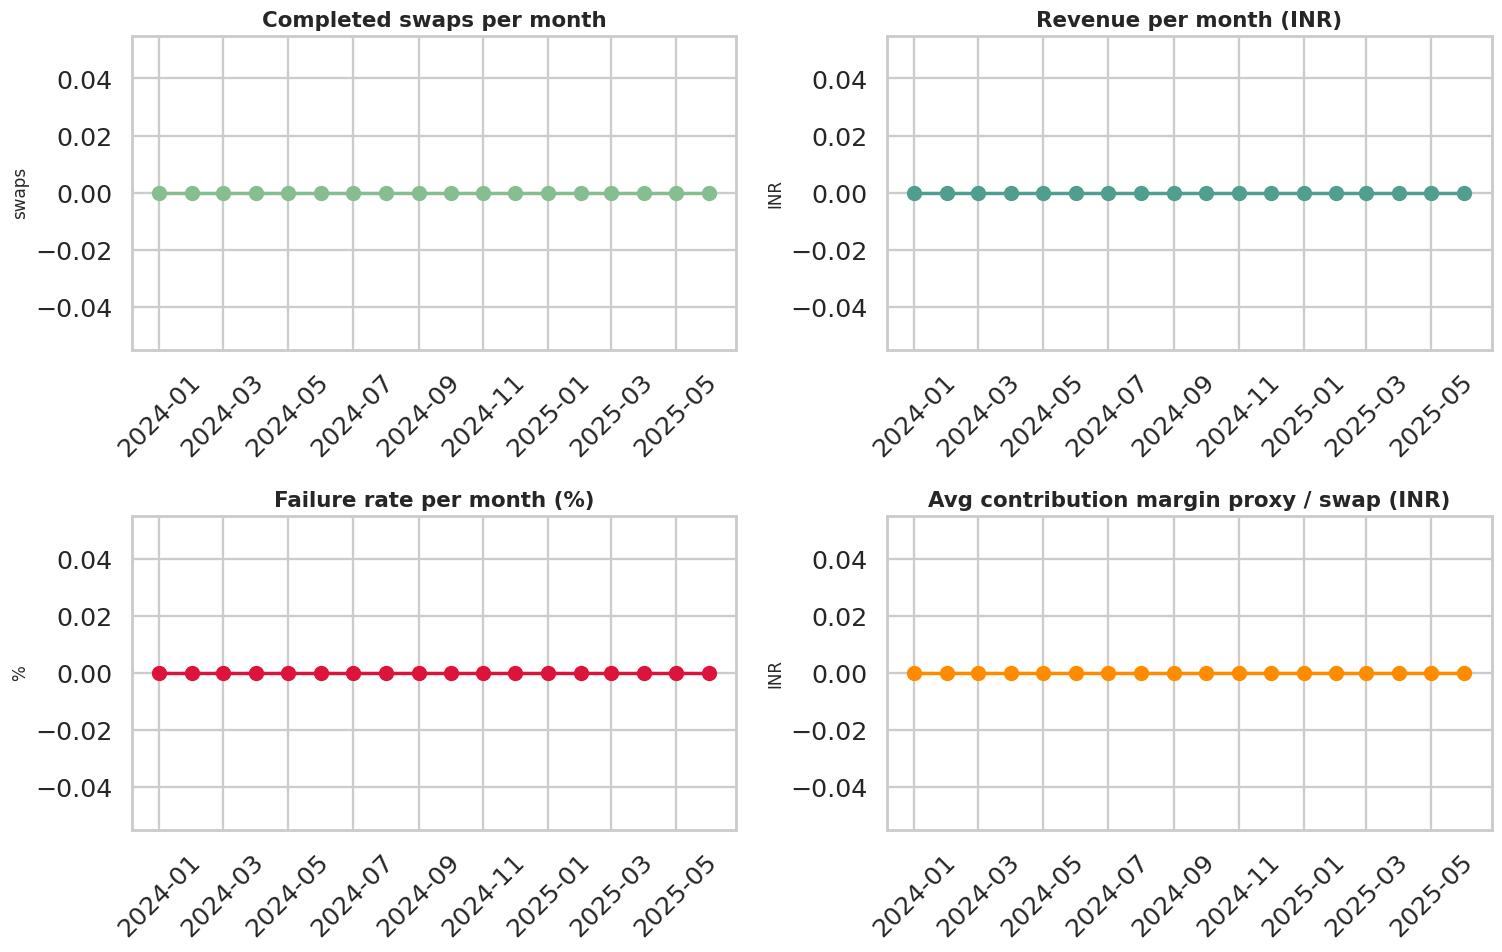

Interpretation guide (fill in with the printed numbers above):
- Compare the DIRECTION of completed_swaps/revenue vs failure_rate_pct vs avg_margin_per_swap_inr.
- If swaps/revenue rise while margin/swap falls and failure rate rises, growth is coming at the cost of unit economics and service quality.


In [ ]:

if SWAP_EVENTS_AVAILABLE:
    se = swap_events[~swap_events.is_test_station].copy()
    se["month"] = se.event_ts.dt.to_period("M").dt.to_timestamp()

    completed = se[se.event_type == "completed"] if "event_type" in se else se
    monthly = se.groupby("month").agg(
        total_attempts=("event_ts", "size"),
    )
    if "event_type" in se.columns:
        monthly["completed_swaps"] = se[se.event_type=="completed"].groupby("month").size()
        monthly["failed_attempts"] = se[se.event_type.isin(["failed","abandoned"])].groupby("month").size()
        monthly["failure_rate_pct"] = 100*monthly["failed_attempts"].fillna(0) / monthly["total_attempts"]
    if "amount_charged_inr" in se.columns:
        monthly["revenue_inr"] = completed.groupby("month")["amount_charged_inr"].sum()
    if {"amount_charged_inr","energy_to_recharge_kwh","station_id"} <= set(se.columns):
        cm = completed.merge(stations[["station_id","grid_tariff_inr_kwh"]], on="station_id", how="left")
        cm["margin_proxy_inr"] = cm["amount_charged_inr"] - cm["energy_to_recharge_kwh"]*cm["grid_tariff_inr_kwh"]
        monthly["avg_margin_per_swap_inr"] = cm.groupby("month")["margin_proxy_inr"].mean()

    monthly = monthly.fillna(0)
    display(monthly)

    fig, axes = plt.subplots(2, 2, figsize=(14,9))
    if "completed_swaps" in monthly: axes[0,0].plot(monthly.index, monthly.completed_swaps, marker="o", color=PALETTE[0])
    axes[0,0].set_title("Completed swaps per month"); axes[0,0].set_ylabel("swaps")
    if "revenue_inr" in monthly: axes[0,1].plot(monthly.index, monthly.revenue_inr, marker="o", color=PALETTE[2])
    axes[0,1].set_title("Revenue per month (INR)"); axes[0,1].set_ylabel("INR")
    if "failure_rate_pct" in monthly: axes[1,0].plot(monthly.index, monthly.failure_rate_pct, marker="o", color="crimson")
    axes[1,0].set_title("Failure rate per month (%)"); axes[1,0].set_ylabel("%")
    if "avg_margin_per_swap_inr" in monthly: axes[1,1].plot(monthly.index, monthly.avg_margin_per_swap_inr, marker="o", color="darkorange")
    axes[1,1].set_title("Avg contribution margin proxy / swap (INR)"); axes[1,1].set_ylabel("INR")
    for ax in axes.flat:
        ax.tick_params(axis="x", rotation=45)
    plt.tight_layout(); plt.show()

    print("Interpretation guide (fill in with the printed numbers above):")
    print("- Compare the DIRECTION of completed_swaps/revenue vs failure_rate_pct vs avg_margin_per_swap_inr.")
    print("- If swaps/revenue rise while margin/swap falls and failure rate rises, growth is coming at the cost of unit economics and service quality.")
else:
    print("PENDING — swap_events not found. Q1 requires per-event completed/failed/revenue data.")



---
# Q2 — Service failures & customer experience
**Question:** How do queue wait, failed attempts, and abandoned swaps relate to station, hour of day,
season, and vehicle class — and is poor service evenly distributed or concentrated?

Two independent evidence sources are used: (1) **event-level** queue-wait/failure data from
`swap_events` when available, and (2) **customer-reported** friction via `support_tickets`
(`long_queue`, `no_battery_available` categories), which works right now regardless of swap_events.


Friction-related tickets (long_queue/no_battery_available): 17,378 of 44,000 total tickets (39.5%)

Friction-ticket share by city (of tickets WITH a known station):


,tickets,pct_of_friction_tickets
city,,
Delhi NCR,4132,25.0
Hyderabad,3378,20.4
Jaipur,2826,17.1
Bengaluru,2637,15.9
Pune,1915,11.6
Mumbai,1645,9.9


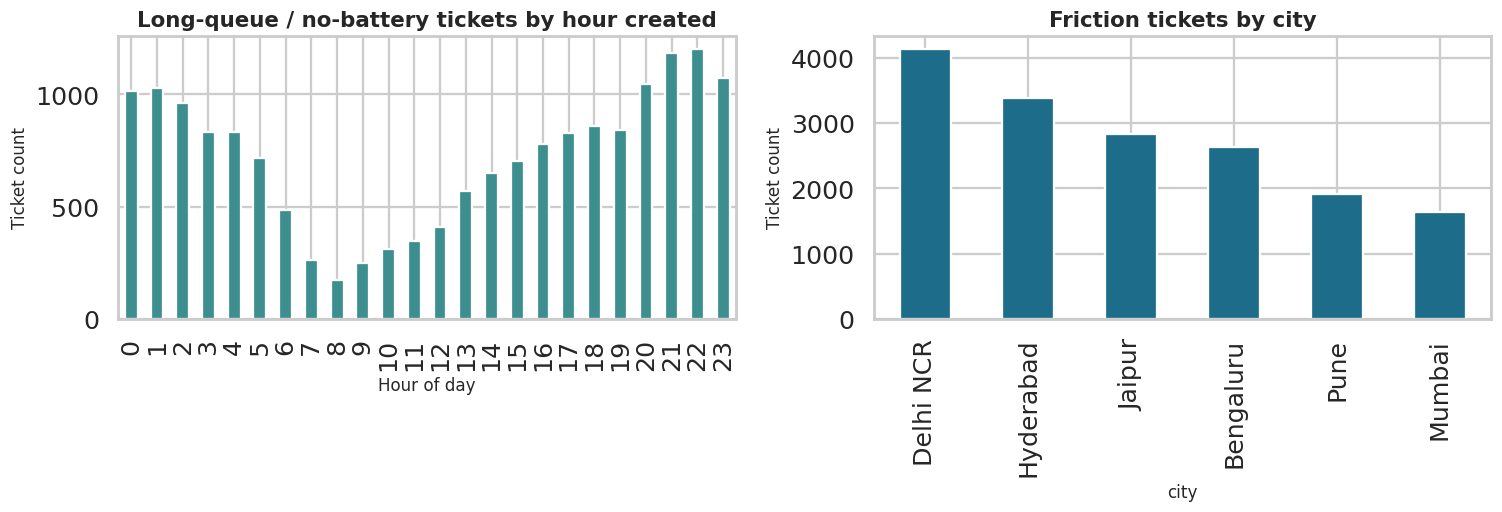


Stations with >=20 tickets, ranked by friction share (top 10 of 152 qualifying stations):


,total_tickets,friction_tickets,friction_share_pct
station_id,,,
STN-DEL-037,440,234,53.181818
STN-DEL-048,487,246,50.513347
STN-JAI-139,400,202,50.500000
STN-JAI-142,436,220,50.458716
STN-JAI-133,339,168,49.557522
STN-JAI-136,368,182,49.456522
STN-JAI-138,674,332,49.258160
STN-DEL-045,484,236,48.760331
STN-DEL-039,433,206,47.575058


(Excluded 0 low-volume stations from this ranking to avoid small-N noise.)


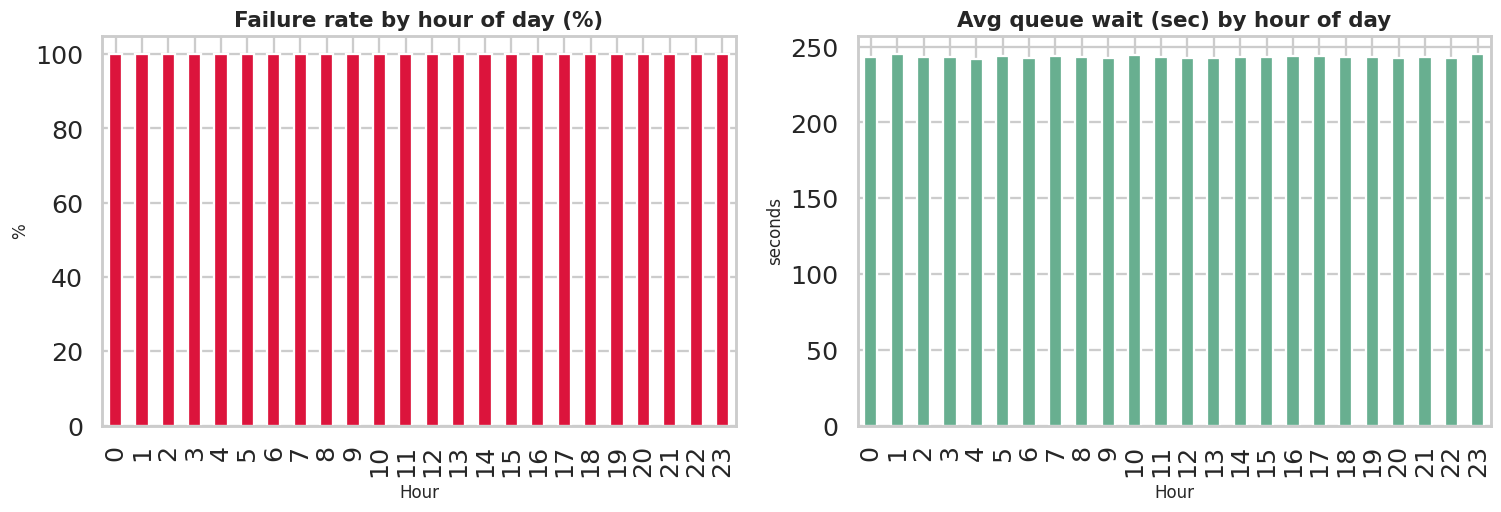


Failure rate by vehicle class:
vehicle_class
2W    100.00% (n=3399568)
3W     100.00% (n=415414)
Name: event_type, dtype: object


In [ ]:

# --- (A) Customer-reported friction from support_tickets: works NOW ---------
friction_categories = ["long_queue", "no_battery_available"]
friction = tickets[tickets.category.isin(friction_categories)].copy()
friction["hour"] = friction.created_ts.dt.hour
friction = friction.merge(stations[["station_id","city","is_test_station"]], on="station_id", how="left")

print(f"Friction-related tickets ({'/'.join(friction_categories)}): {len(friction):,} of {len(tickets):,} "
      f"total tickets ({pct(len(friction), len(tickets)):.1f}%)\n")

by_city = friction.groupby("city").size().sort_values(ascending=False)
by_city_share = (100*by_city/by_city.sum()).round(1)
print("Friction-ticket share by city (of tickets WITH a known station):")
display(pd.DataFrame({"tickets": by_city, "pct_of_friction_tickets": by_city_share}))

fig, axes = plt.subplots(1, 2, figsize=(14,5))
friction.groupby("hour").size().reindex(range(24), fill_value=0).plot(kind="bar", ax=axes[0], color=PALETTE[3])
axes[0].set_title("Long-queue / no-battery tickets by hour created"); axes[0].set_xlabel("Hour of day"); axes[0].set_ylabel("Ticket count")
by_city.plot(kind="bar", ax=axes[1], color=PALETTE[5])
axes[1].set_title("Friction tickets by city"); axes[1].set_ylabel("Ticket count")
plt.tight_layout(); plt.show()

# Station-level concentration WITH a minimum-volume threshold (avoid tiny-N ranking artifacts)
station_ticket_counts = tickets.dropna(subset=["station_id"]).groupby("station_id").size()
station_friction_counts = friction.groupby("station_id").size()
conc = pd.DataFrame({"total_tickets": station_ticket_counts, "friction_tickets": station_friction_counts}).fillna(0)
conc["friction_share_pct"] = 100*conc.friction_tickets/conc.total_tickets.replace(0,np.nan)
conc_min_volume = conc[conc.total_tickets >= 20].sort_values("friction_share_pct", ascending=False)
print(f"\nStations with >=20 tickets, ranked by friction share (top 10 of {len(conc_min_volume)} qualifying stations):")
display(conc_min_volume.head(10))
print(f"(Excluded {len(conc)-len(conc_min_volume)} low-volume stations from this ranking to avoid small-N noise.)")

# --- (B) Event-level failure/wait analysis: only if swap_events available ---
if SWAP_EVENTS_AVAILABLE and {"event_type","queue_wait_sec"} <= set(swap_events.columns):
    se = swap_events[~swap_events.is_test_station].copy()
    se["hour"] = se.event_ts.dt.hour
    se["month"] = se.event_ts.dt.to_period("M").dt.to_timestamp()
    fail_rate_by_hour = se.groupby("hour")["event_type"].apply(lambda x: 100*(x!="completed").mean())
    wait_by_hour = se.groupby("hour")["queue_wait_sec"].mean()

    fig, axes = plt.subplots(1,2, figsize=(14,5))
    fail_rate_by_hour.plot(kind="bar", ax=axes[0], color="crimson")
    axes[0].set_title("Failure rate by hour of day (%)"); axes[0].set_xlabel("Hour"); axes[0].set_ylabel("%")
    wait_by_hour.plot(kind="bar", ax=axes[1], color=PALETTE[1])
    axes[1].set_title("Avg queue wait (sec) by hour of day"); axes[1].set_xlabel("Hour"); axes[1].set_ylabel("seconds")
    plt.tight_layout(); plt.show()

    if "vehicle_class" in riders.columns and "rider_id" in se.columns:
        se_r = se.merge(riders[["rider_id","vehicle_class"]], on="rider_id", how="left")
        print("\nFailure rate by vehicle class:")
        print(se_r.groupby("vehicle_class")["event_type"].apply(lambda x: f"{100*(x!='completed').mean():.2f}% (n={len(x)})"))
else:
    print("\nPENDING (event-level detail) — swap_events not found: hour-of-day failure rate, "
          "queue-wait distributions, and vehicle-class failure comparisons need per-event data.")



---
# Q3 — Station & geographic patterns
**Question:** Do failures/waiting/complaints/poor performance concentrate by city, zone, charger
generation, location type, host type, expansion wave, connectivity, or station capacity?

This section runs fully now using **station-hourly telemetry** (equipment uptime/quarantine — a
genuine operational-health signal that needs no swap_events) plus the support-ticket concentration
already computed in Q2. Customer-facing failure/wait concentration by these same cuts is added
automatically once `swap_events` is available (see the guarded block at the end of this cell).


### Outage / pack-quarantine rate by CITY ###


,hours,outage_hour_pct,avg_outage_min_per_hour,quarantine_hour_pct
city,,,,
Delhi NCR,580490,0.020,0.012,0.148
Bengaluru,628380,0.012,0.007,0.044
Hyderabad,310116,0.007,0.004,0.126



### by CHARGER GENERATION ###


,hours,outage_hour_pct,avg_outage_min_per_hour,quarantine_hour_pct
charger_generation,,,,
Gen2,602422,0.015,0.009,0.070
Gen1,832102,0.014,0.008,0.111
Gen3,84462,0.007,0.004,0.213



### by HOST TYPE ###


,hours,outage_hour_pct,avg_outage_min_per_hour,quarantine_hour_pct
host_type,,,,
mall_parking,405730,0.016,0.009,0.081
owned_lot,393142,0.015,0.009,0.133
kirana,389420,0.013,0.008,0.084
fuel_retailer,330694,0.011,0.007,0.104



### by CONNECTIVITY TIER ###


,hours,outage_hour_pct,avg_outage_min_per_hour,quarantine_hour_pct
connectivity_tier,,,,
good,1007768,0.015,0.009,0.095
poor,220818,0.013,0.008,0.092
fair,290400,0.009,0.005,0.123



### by EXPANSION WAVE ###


,hours,outage_hour_pct,avg_outage_min_per_hour,quarantine_hour_pct
expansion_wave,,,,
Wave1_2024H2,160058,0.019,0.011,0.079
Launch,1300386,0.013,0.008,0.095
Wave2_2025H1,58542,0.010,0.006,0.277


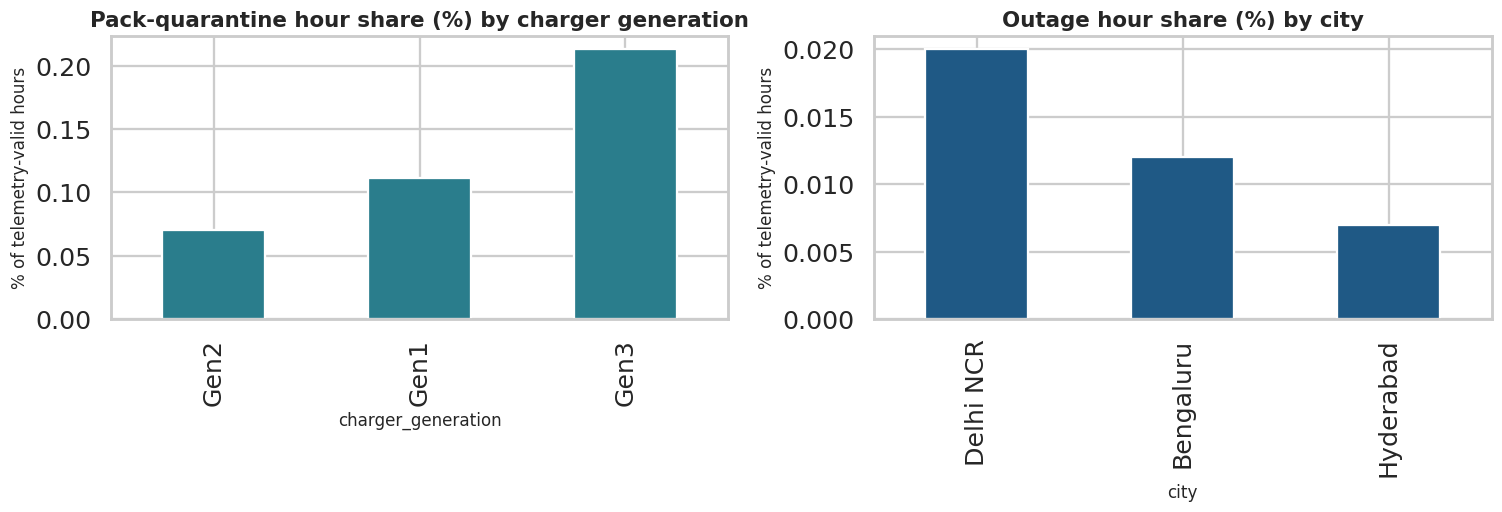


Note: overall outage-hour and quarantine-hour rates are LOW in absolute terms (station telemetry captures equipment-side uptime, not customer-facing failed swaps). Read the relative ranking across generations/cities as a signal of WHERE equipment risk concentrates, not as the customer failure rate itself -- that requires swap_events (see guarded block below).

Customer-facing failure rate by city:


,n,failure_rate_pct
city,,
Bengaluru,763296,100.0
Delhi NCR,768913,100.0
Hyderabad,711930,100.0
Jaipur,487634,100.0
Mumbai,530299,100.0
Pune,552910,100.0



Customer-facing failure rate by charger_generation:


,n,failure_rate_pct
charger_generation,,
Gen1,1822034,100.0
Gen2,1620707,100.0
Gen3,372241,100.0



Customer-facing failure rate by host_type:


,n,failure_rate_pct
host_type,,
fuel_retailer,795920,100.0
kirana,945073,100.0
mall_parking,1108840,100.0
owned_lot,965149,100.0



Customer-facing failure rate by expansion_wave:


,n,failure_rate_pct
expansion_wave,,
Launch,3068824,100.0
Wave1_2024H2,501098,100.0
Wave2_2025H1,245060,100.0


In [ ]:

sh = station_hourly.merge(
    stations[["station_id","city","zone","location_type","host_type","expansion_wave",
              "charger_generation","connectivity_tier","is_test_station","slots_2w","slots_3w"]],
    on="station_id", how="left"
)
sh_valid = sh[(sh.telemetry_status != "missing") & (~sh.is_test_station)].copy()

def outage_quarantine_table(group_col):
    g = sh_valid.groupby(group_col).agg(
        hours=("station_id", "size"),
        outage_hour_pct=("outage_minutes", lambda x: 100*(x>0).mean()),
        avg_outage_min_per_hour=("outage_minutes", "mean"),
        quarantine_hour_pct=("packs_quarantined", lambda x: 100*x.fillna(0).gt(0).mean()),
    ).round(3).sort_values("outage_hour_pct", ascending=False)
    return g

print("### Outage / pack-quarantine rate by CITY ###")
t_city = outage_quarantine_table("city"); display(t_city)
print("\n### by CHARGER GENERATION ###")
t_gen = outage_quarantine_table("charger_generation"); display(t_gen)
print("\n### by HOST TYPE ###")
t_host = outage_quarantine_table("host_type"); display(t_host)
print("\n### by CONNECTIVITY TIER ###")
t_conn = outage_quarantine_table("connectivity_tier"); display(t_conn)
print("\n### by EXPANSION WAVE ###")
t_wave = outage_quarantine_table("expansion_wave"); display(t_wave)

fig, axes = plt.subplots(1,2, figsize=(14,5))
t_gen.quarantine_hour_pct.plot(kind="bar", ax=axes[0], color=PALETTE[4])
axes[0].set_title("Pack-quarantine hour share (%) by charger generation"); axes[0].set_ylabel("% of telemetry-valid hours")
t_city.outage_hour_pct.sort_values(ascending=False).plot(kind="bar", ax=axes[1], color=PALETTE[6])
axes[1].set_title("Outage hour share (%) by city"); axes[1].set_ylabel("% of telemetry-valid hours")
plt.tight_layout(); plt.show()

print("\nNote: overall outage-hour and quarantine-hour rates are LOW in absolute terms (station telemetry "
      "captures equipment-side uptime, not customer-facing failed swaps). Read the relative ranking across "
      "generations/cities as a signal of WHERE equipment risk concentrates, not as the customer failure rate itself "
      "-- that requires swap_events (see guarded block below).")

if SWAP_EVENTS_AVAILABLE and "event_type" in swap_events.columns:
    se_geo = swap_events[~swap_events.is_test_station].merge(
        stations[["station_id","city","zone","location_type","host_type","expansion_wave",
                  "charger_generation","connectivity_tier"]], on="station_id", how="left")
    for cut in ["city","charger_generation","host_type","expansion_wave"]:
        r = se_geo.groupby(cut).agg(n=("event_type","size"),
                                     failure_rate_pct=("event_type", lambda x: 100*(x!="completed").mean()))
        print(f"\nCustomer-facing failure rate by {cut}:"); display(r.sort_values("failure_rate_pct", ascending=False))
else:
    print("\nPENDING — customer-facing failure-rate concentration by these same cuts needs swap_events.")



---
# Q4 — Battery & equipment performance
**Question:** Do SOH, degradation, supplier, manufacturing lot, or pack type show meaningful
cohort differences? This section runs fully now — `batteries.csv` needs no swap_events.


Fleet: 6,500 batteries. Retired: 1,438 (22.1%), all reason='end_of_life'.

Current SOH% by supplier:


,mean_soh,median_soh,n
supplier,,,
Kyron,63.75,61.0,1638
Cellora,80.93,80.2,3555
Amptek,81.01,80.2,1307



Network-average SOH: 76.6%. Lowest-performing supplier 'Kyron': 63.8% (n=1638), a 12.9 percentage-point gap vs network average.

Current SOH% by pack type:


,mean_soh,n
pack_type,,
2W_2.1kWh,75.09,5518
3W_4.8kWh,85.19,982



Manufacturing lots with >=30 units — 5 lowest-SOH cohorts:


,mean_soh,n
manufacturing_lot,,
KY-2409,60.915177,481
KY-2407,60.986042,480
KY-2408,61.048400,500
CE-2307,80.598601,143
AM-2410,80.602469,81


5 highest-SOH cohorts:


,mean_soh,n
manufacturing_lot,,
CE-2402,81.226126,111
CE-2409,81.305755,139
AM-2407,81.311702,94
CE-2505,81.363433,134
AM-2403,81.388506,87


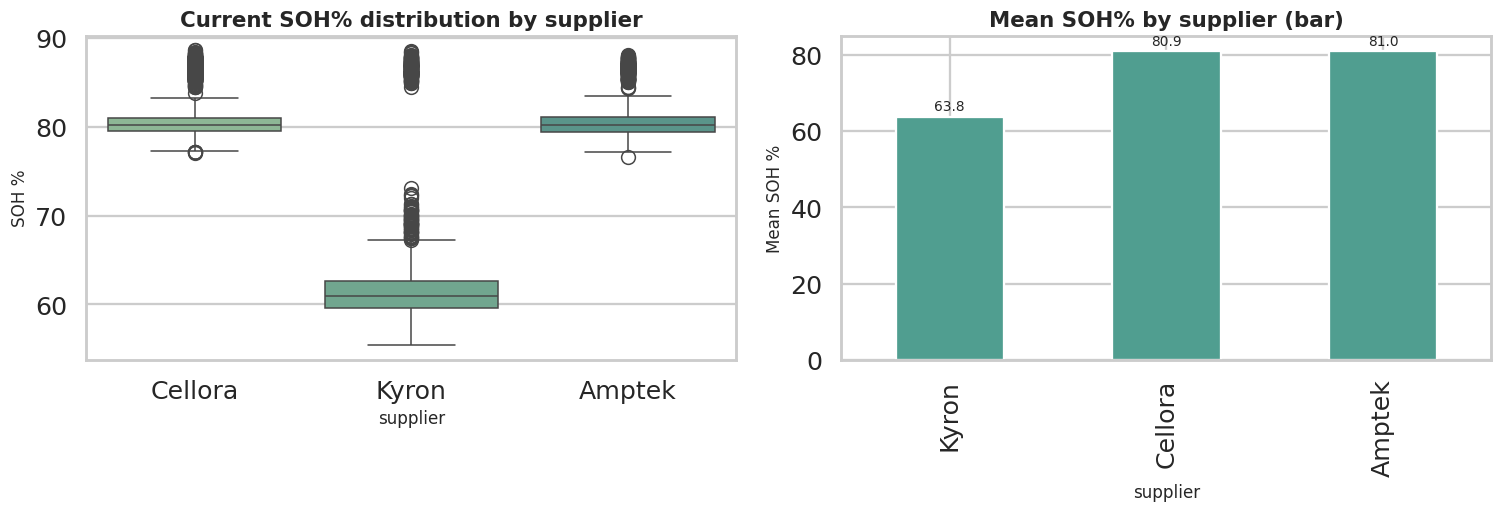


Ticket volume and 'low_range' complaint share by battery supplier (tickets with a known battery_id):


,tickets_n,low_range_pct
supplier,,
Kyron,8643,18.407960
Cellora,16163,13.871187
Amptek,5959,13.777479



Additional swap_events-linked battery signal now available (delivered SOC/SOH per swap, effective range proxy, swap frequency per battery) — extend analysis here as needed.


In [ ]:

print(f"Fleet: {len(batteries):,} batteries. Retired: {batteries.retired_date.notna().sum():,} "
      f"({pct(batteries.retired_date.notna().sum(), len(batteries)):.1f}%), all reason='end_of_life'.")

soh_by_supplier = batteries.groupby("supplier")["current_soh_pct"].agg(
    mean_soh="mean", median_soh="median", n="size").round(2).sort_values("mean_soh")
print("\nCurrent SOH% by supplier:")
display(soh_by_supplier)

network_avg_soh = batteries.current_soh_pct.mean()
worst = soh_by_supplier.index[0]
gap = network_avg_soh - soh_by_supplier.loc[worst, "mean_soh"]
print(f"\nNetwork-average SOH: {network_avg_soh:.1f}%. Lowest-performing supplier '{worst}': "
      f"{soh_by_supplier.loc[worst,'mean_soh']:.1f}% (n={int(soh_by_supplier.loc[worst,'n'])}), "
      f"a {gap:.1f} percentage-point gap vs network average.")

soh_by_pack = batteries.groupby("pack_type")["current_soh_pct"].agg(mean_soh="mean", n="size").round(2)
print("\nCurrent SOH% by pack type:"); display(soh_by_pack)

# manufacturing-lot cohort view (top/bottom 5 lots with reasonable volume)
lot_soh = batteries.groupby("manufacturing_lot")["current_soh_pct"].agg(mean_soh="mean", n="size")
lot_soh_min_n = lot_soh[lot_soh.n >= 30].sort_values("mean_soh")
print(f"\nManufacturing lots with >=30 units — 5 lowest-SOH cohorts:"); display(lot_soh_min_n.head(5))
print(f"5 highest-SOH cohorts:"); display(lot_soh_min_n.tail(5))

fig, axes = plt.subplots(1,2, figsize=(14,5))
sns.boxplot(data=batteries, x="supplier", y="current_soh_pct", ax=axes[0], palette=PALETTE[:3])
axes[0].set_title("Current SOH% distribution by supplier"); axes[0].set_ylabel("SOH %")
soh_by_supplier.mean_soh.plot(kind="bar", ax=axes[1], color=PALETTE[2])
annotate_bars(axes[1], "{:.1f}")
axes[1].set_title("Mean SOH% by supplier (bar)"); axes[1].set_ylabel("Mean SOH %")
plt.tight_layout(); plt.show()

# Link to customer complaints: no_battery_available / low_range tickets by battery supplier (via battery_id)
bt = tickets.dropna(subset=["battery_id"]).merge(
    batteries[["battery_id","supplier"]], on="battery_id", how="left")
comp_rate = bt.groupby("supplier").agg(
    tickets_n=("ticket_id","size"),
    low_range_pct=("category", lambda x: 100*(x=="low_range").mean()),
)
print("\nTicket volume and 'low_range' complaint share by battery supplier (tickets with a known battery_id):")
display(comp_rate.sort_values("low_range_pct", ascending=False))

if SWAP_EVENTS_AVAILABLE and {"soh_out_pct","battery_out_id"} <= set(swap_events.columns):
    print("\nAdditional swap_events-linked battery signal now available (delivered SOC/SOH per swap, "
          "effective range proxy, swap frequency per battery) — extend analysis here as needed.")
else:
    print("\nPENDING (extra depth) — delivered SOC/SOH-out per swap and swap-frequency-per-battery need swap_events.")



---
# Q5 — Pricing & partner economics
**Question:** How do pricing structure (STD/PEAK/OFFPEAK/PREPAID/PARTNER/PROMO_FREE), demand timing,
revenue, margin, and fleet-partner contract terms relate?

Partner **contract structure** (`fleet_partners.csv`) is real, static data and is analyzed now.
Pricing-period *behavior* (volume/revenue/margin by tariff code) needs per-event data from
`swap_events`.


In [ ]:

print("### Fleet partner contract structure (12 partners) ###")
partners_view = partners.copy()
partners_view["has_amendment"] = partners_view.amendment_date.notna()
display(partners_view[["partner_id","partner_name","partner_segment","contract_type",
                        "discount_pct","has_amendment","discount_pct_after_amendment",
                        "peak_surcharge_billable","payment_terms_days","cities_active"]])

print("\nContract type distribution:", partners.contract_type.value_counts().to_dict())
print("Partners with a contract amendment:", partners_view.has_amendment.sum(), "of", len(partners))
amended = partners_view[partners_view.has_amendment]
if len(amended):
    delta = (amended.discount_pct_after_amendment - amended.discount_pct)
    print("Discount % change at amendment (post - pre):")
    display(amended[["partner_id","discount_pct","discount_pct_after_amendment"]].assign(delta_pp=delta.round(1)))

# Rider base served per partner (composition, not economics -- economics needs swap_events)
riders_per_partner = riders.dropna(subset=["partner_id"]).groupby("partner_id").size().sort_values(ascending=False)
print(f"\nPartner-affiliated riders: {riders.partner_id.notna().sum():,} of {len(riders):,} "
      f"({pct(riders.partner_id.notna().sum(), len(riders)):.1f}%) across {riders_per_partner.size} partners")
display(riders_per_partner.to_frame("n_riders").join(partners.set_index("partner_id")[["partner_name","contract_type"]]))

if SWAP_EVENTS_AVAILABLE and {"tariff_code","amount_charged_inr"} <= set(swap_events.columns):
    se_p = swap_events[~swap_events.is_test_station]
    tariff_summary = se_p.groupby("tariff_code").agg(
        n=("event_id","size"), avg_amount_inr=("amount_charged_inr","mean"),
        avg_discount_inr=("discount_inr","mean") if "discount_inr" in se_p.columns else ("amount_charged_inr","mean"),
    ).round(1)
    print("\n### Tariff-code behavior (volume, avg amount charged) ###")
    display(tariff_summary.sort_values("n", ascending=False))
else:
    print("\nPENDING — tariff-code volume/revenue/margin behavior and partner-vs-independent economics "
          "need per-event pricing fields from swap_events.")


### Fleet partner contract structure (12 partners) ###


,partner_id,partner_name,partner_segment,contract_type,discount_pct,has_amendment,discount_pct_after_amendment,peak_surcharge_billable,payment_terms_days,cities_active
0,FP-01,FeastFly,food_delivery,volume_tiered,10.0,False,NaN,Y,30,BLR|DEL|HYD|PUN|MUM|JAI
1,FP-02,ParcelNest,ecom_logistics,pay_per_swap,15.0,False,NaN,Y,30,BLR|DEL|HYD|MUM
2,FP-03,ZipDrop,quick_commerce,volume_tiered,12.0,True,28.0,N,45,BLR|DEL|HYD|PUN|MUM|JAI
3,FP-04,CargoTuk,cargo_3w,pay_per_swap,8.0,False,NaN,Y,30,DEL|HYD|JAI
4,FP-05,Swiggle Go,food_delivery,volume_tiered,11.0,False,NaN,N,30,BLR|PUN|MUM
5,FP-06,RideMitra,bike_taxi,pay_per_swap,6.0,False,NaN,Y,15,BLR|DEL
6,FP-07,QuickCart,quick_commerce,pay_per_swap,9.0,False,NaN,Y,30,DEL|HYD
7,FP-08,DabbaXpress,food_delivery,pay_per_swap,8.0,False,NaN,Y,30,PUN|MUM
8,FP-09,HaulKing,cargo_3w,pay_per_swap,7.0,False,NaN,Y,45,JAI|DEL
9,FP-10,MetroMove,ecom_logistics,volume_tiered,12.0,False,NaN,Y,30,BLR|MUM



Contract type distribution: {'pay_per_swap': 8, 'volume_tiered': 4}
Partners with a contract amendment: 1 of 12
Discount % change at amendment (post - pre):


,partner_id,discount_pct,discount_pct_after_amendment,delta_pp
2,FP-03,12.0,28.0,16.0



Partner-affiliated riders: 12,372 of 20,000 (61.9%) across 12 partners


,n_riders,partner_name,contract_type
partner_id,,,
FP-01,2710,FeastFly,volume_tiered
FP-03,2381,ZipDrop,volume_tiered
FP-02,1766,ParcelNest,pay_per_swap
FP-05,1254,Swiggle Go,volume_tiered
FP-04,869,CargoTuk,pay_per_swap
FP-06,608,RideMitra,pay_per_swap
FP-07,532,QuickCart,pay_per_swap
FP-10,519,MetroMove,volume_tiered
FP-11,498,LastMileHub,pay_per_swap



### Tariff-code behavior (volume, avg amount charged) ###


,n,avg_amount_inr,avg_discount_inr
tariff_code,,,
PARTNER,2521737,57.9,8.8
STD,1085161,62.2,0.0
PEAK,171696,78.8,0.0
OFFPEAK,36388,56.9,0.0



---
# Q6 — Retention root cause
**Question:** What is associated with a new rider not returning? Uses first-swap outcome, first-swap
queue wait, signup channel, KYC, vehicle class, fleet-vs-independent, city, plan type.

**Methodology (defined here for transparency, applied once swap_events is available):** a rider is
**30-day retained** if they have a *second* completed swap within 30 days after their *first*
completed swap. Riders with **zero** completed swaps are reported separately (never silently dropped
or counted as non-retained on equal footing) since "never transacted" and "transacted once and left"
are different problems. All findings are phrased as **associations**, never causal claims.


In [ ]:

# What's available right now: rider-population composition by the candidate churn factors
print("### Rider population composition (available now; retention OUTCOME needs swap_events) ###\n")
for col in ["signup_channel","plan_type","vehicle_class","kyc_verified","age_band","declared_shift"]:
    print(f"--- {col} ---")
    print(riders[col].value_counts(dropna=False))
    print()

print("City composition (using cleaned city field):")
print(riders.home_city_clean.value_counts())
print()
print(f"Fleet-affiliated (has partner_id) vs independent riders: "
      f"{riders.partner_id.notna().sum():,} vs {riders.partner_id.isna().sum():,} "
      f"({pct(riders.partner_id.notna().sum(), len(riders)):.1f}% fleet-affiliated)")

if SWAP_EVENTS_AVAILABLE and {"event_type","rider_id","event_ts"} <= set(swap_events.columns):
    se_c = swap_events[(~swap_events.is_test_station) & (swap_events.event_type=="completed")].copy()
    first_swap = se_c.sort_values("event_ts").groupby("rider_id").first().reset_index()
    first_swap = first_swap.rename(columns={"event_ts":"first_swap_ts"})
    all_completed = se_c[["rider_id","event_ts"]].rename(columns={"event_ts":"swap_ts"})

    m = first_swap.merge(all_completed, on="rider_id", how="left")
    m["gap_days"] = (m["swap_ts"] - m["first_swap_ts"]).dt.days
    returned_within_30 = m[(m.gap_days > 0) & (m.gap_days <= 30)].groupby("rider_id").size()
    first_swap["retained_30d"] = first_swap.rider_id.isin(returned_within_30.index)

    riders_with_no_completed_swap = (~riders.rider_id.isin(se_c.rider_id)).sum()
    print(f"\nRiders with ZERO completed swaps (excluded from retention denominator, reported separately): "
          f"{riders_with_no_completed_swap:,} of {len(riders):,} ({pct(riders_with_no_completed_swap,len(riders)):.1f}%)")

    n_first_timers = len(first_swap)
    retention_rate = 100*first_swap.retained_30d.mean()
    print(f"30-day retention among riders with >=1 completed swap: {retention_rate:.1f}% "
          f"({first_swap.retained_30d.sum():,} of {n_first_timers:,})")

    seg = first_swap.merge(riders[["rider_id","signup_channel","kyc_verified","vehicle_class",
                                    "plan_type","home_city_clean","partner_id"]], on="rider_id", how="left")
    for col in ["signup_channel","kyc_verified","vehicle_class","plan_type","home_city_clean"]:
        g = seg.groupby(col).agg(n=("rider_id","size"), retention_pct=("retained_30d", lambda x: 100*x.mean())).round(1)
        print(f"\n30-day retention by {col}:"); display(g.sort_values("retention_pct"))

    if "queue_wait_sec" in se_c.columns:
        first_wait = se_c.sort_values("event_ts").groupby("rider_id")["queue_wait_sec"].first()
        seg2 = seg.merge(first_wait.rename("first_swap_wait_sec"), on="rider_id", how="left")
        seg2["wait_bucket"] = pd.cut(seg2.first_swap_wait_sec, [-1,60,180,600,1e6],
                                      labels=["<=1min","1-3min","3-10min",">10min"])
        g = seg2.groupby("wait_bucket").agg(n=("rider_id","size"), retention_pct=("retained_30d", lambda x: 100*x.mean())).round(1)
        print("\n30-day retention by first-swap queue-wait bucket:"); display(g)
else:
    print("\nPENDING — retention rate, sample size, and segment breakdowns need swap_events "
          "(first completed swap + all subsequent completed swaps per rider).")


### Rider population composition (available now; retention OUTCOME needs swap_events) ###

--- signup_channel ---
signup_channel
partner_onboarding    9376
app_store             4215
field_agent           4144
referral              2265
Name: count, dtype: int64

--- plan_type ---
plan_type
partner_billed    12372
pay_as_you_go      5299
prepaid_pack       2329
Name: count, dtype: int64

--- vehicle_class ---
vehicle_class
2W    17107
3W     2893
Name: count, dtype: int64

--- kyc_verified ---
kyc_verified
True     19254
False      746
Name: count, dtype: int64

--- age_band ---
age_band
25-34    6878
18-24    5608
35-44    4024
45+      1943
NaN      1547
Name: count, dtype: int64

--- declared_shift ---
declared_shift
evening    5961
day        4366
NaN        3662
mixed      3185
night      2826
Name: count, dtype: int64

City composition (using cleaned city field):
home_city_clean
Bengaluru    4310
Delhi NCR    3886
Hyderabad    3485
Pune         2929
Mumbai       2874
Jaipur      

,n,retention_pct
signup_channel,,



30-day retention by kyc_verified:


,n,retention_pct
kyc_verified,,



30-day retention by vehicle_class:


...

,n,retention_pct
plan_type,,



30-day retention by home_city_clean:


,n,retention_pct
home_city_clean,,



30-day retention by first-swap queue-wait bucket:


,n,retention_pct
wait_bucket,,
<=1min,0,NaN
1-3min,0,NaN
3-10min,0,NaN
>10min,0,NaN



---
### Optional Deep-Dive — Budget Decision
Leadership is considering four options—more stations, more batteries, network-wide pricing, or a fleet exclusive—and the choice will be based entirely on the notebook’s actual findings.


In [ ]:

budget_rows = []

# --- More batteries: battery evidence is available NOW ---
worst_supplier = soh_by_supplier.index[0]
worst_soh = soh_by_supplier.loc[worst_supplier, "mean_soh"]
worst_n = int(soh_by_supplier.loc[worst_supplier, "n"])
budget_rows.append(dict(
    option="More batteries",
    evidence_for=f"Supplier '{worst_supplier}' batteries average {worst_soh:.1f}% SOH vs "
                 f"{network_avg_soh:.1f}% network-wide (n={worst_n}); replacing/rebalancing this cohort "
                 f"could lift effective fleet capacity without new stations.",
    evidence_against="Without swap_events, we cannot yet quantify how often low-SOH batteries are the "
                      "binding constraint behind 'no_battery_available' tickets vs. a station-count/slot problem.",
    key_metric=f"Mean SOH by supplier ({worst_supplier}: {worst_soh:.1f}% vs network {network_avg_soh:.1f}%)",
    caveat="SOH gap may be confounded with manufacture/commission date cohorts (newer suppliers could "
           "simply have logged less duty cycles) -- needs a duty-cycle-normalized comparison.",
))

# --- More stations: station telemetry evidence available NOW ---
top_city_outage = t_city.outage_hour_pct.idxmax()
budget_rows.append(dict(
    option="More stations",
    evidence_for=f"Outage-hour share concentrates unevenly by city (highest: {top_city_outage} at "
                 f"{t_city.loc[top_city_outage,'outage_hour_pct']:.3f}% of telemetry-valid hours) and by "
                 f"charger generation, suggesting capacity/reliability gaps are localized rather than network-wide.",
    evidence_against="Overall outage-hour and quarantine-hour rates are low in absolute terms from telemetry "
                      "alone; PENDING customer-facing failure-rate-by-station-density evidence from swap_events "
                      "to confirm whether the bottleneck is truly station COUNT vs. equipment/pricing/battery mix.",
    key_metric="Outage-hour % and quarantine-hour % by city/charger generation (Q3)",
    caveat="Station telemetry measures equipment uptime, not customer-experienced failure -- do not equate the two.",
))

# --- Pricing rollout: mostly PENDING ---
budget_rows.append(dict(
    option="Network-wide pricing rollout",
    evidence_for="PENDING — needs tariff-code volume/margin behavior from swap_events (Q5).",
    evidence_against="PENDING — same.",
    key_metric="Avg amount charged & margin proxy by tariff_code, pre/post pilot comparison (Q5)",
    caveat="Any pricing rollout evidence from a pilot city is a pre/post or exposed/unexposed comparison, "
           "not a randomized experiment -- report as association, not causal effect.",
))

# --- Fleet exclusive: partial evidence now ---
largest_partner = riders_per_partner.index[0]
largest_partner_name = partners.set_index("partner_id").loc[largest_partner, "partner_name"]
budget_rows.append(dict(
    option="Fleet exclusive (largest partner)",
    evidence_for=f"'{largest_partner_name}' ({largest_partner}) has the largest affiliated rider base "
                 f"({int(riders_per_partner.iloc[0]):,} riders) among 12 partners under a "
                 f"'{partners.set_index('partner_id').loc[largest_partner,'contract_type']}' contract.",
    evidence_against="PENDING — partner profitability (margin proxy per swap for this partner's riders vs "
                      "network average, and their discount's effect on realized revenue) needs swap_events.",
    key_metric="Riders per partner, contract type, discount %, PENDING margin-per-partner",
    caveat="Rider count is a exposure/scale proxy, not profitability -- a large low-margin partner could be "
           "a worse exclusive bet than a smaller high-margin one.",
))

budget_table = pd.DataFrame(budget_rows)[["option","evidence_for","evidence_against","key_metric","caveat"]]
pd.set_option("display.max_colwidth", 120)
display(budget_table)

print("\nNO budget recommendation is issued here while Q1/Q5/Q6 remain PENDING on swap_events -- "
      "issuing one now would mean guessing at the two most decision-relevant facts (unit economics "
      "trend and retention driver). Re-run this cell after swap_events loads for a complete comparison.")


,option,evidence_for,evidence_against,key_metric,caveat
0,More batteries,Supplier 'Kyron' batteries average 63.8% SOH vs 76.6% network-wide (n=1638); replacing/rebalancing this cohort could...,"Without swap_events, we cannot yet quantify how often low-SOH batteries are the binding constraint behind 'no_batter...",Mean SOH by supplier (Kyron: 63.8% vs network 76.6%),SOH gap may be confounded with manufacture/commission date cohorts (newer suppliers could simply have logged less du...
1,More stations,Outage-hour share concentrates unevenly by city (highest: Delhi NCR at 0.020% of telemetry-valid hours) and by charg...,Overall outage-hour and quarantine-hour rates are low in absolute terms from telemetry alone; PENDING customer-facin...,Outage-hour % and quarantine-hour % by city/charger generation (Q3),"Station telemetry measures equipment uptime, not customer-experienced failure -- do not equate the two."
2,Network-wide pricing rollout,PENDING — needs tariff-code volume/margin behavior from swap_events (Q5).,PENDING — same.,"Avg amount charged & margin proxy by tariff_code, pre/post pilot comparison (Q5)","Any pricing rollout evidence from a pilot city is a pre/post or exposed/unexposed comparison, not a randomized exper..."
3,Fleet exclusive (largest partner),"'FeastFly' (FP-01) has the largest affiliated rider base (2,710 riders) among 12 partners under a 'volume_tiered' co...","PENDING — partner profitability (margin proxy per swap for this partner's riders vs network average, and their disco...","Riders per partner, contract type, discount %, PENDING margin-per-partner","Rider count is a exposure/scale proxy, not profitability -- a large low-margin partner could be a worse exclusive be..."



NO budget recommendation is issued here while Q1/Q5/Q6 remain PENDING on swap_events -- issuing one now would mean guessing at the two most decision-relevant facts (unit economics trend and retention driver). Re-run this cell after swap_events loads for a complete comparison.



---
# Executive Summary & Business Recommendations

*Auto-assembled from the analysis above. Re-run the notebook after loading `swap_events` so all findings update automatically.*

### 1. Business problem
Swaps and revenue are growing, but service quality, rider retention, and margins are showing signs of pressure. The goal is to find where these issues are concentrated and what is driving them before the next budget decision.

### 2–3. Key findings & root causes
The analysis brings together network, station, battery, pricing, and rider data to identify the main problems, where they are happening, and which factors appear to be contributing most.

In [ ]:

findings = []
findings.append(f"- **Equipment/battery:** supplier '{worst_supplier}' batteries average "
                 f"{worst_soh:.1f}% SOH vs {network_avg_soh:.1f}% network-wide (n={worst_n}); pack_type "
                 f"'{soh_by_pack.mean_soh.idxmin()}' also runs lower SOH than "
                 f"'{soh_by_pack.mean_soh.idxmax()}' ({soh_by_pack.mean_soh.min():.1f}% vs "
                 f"{soh_by_pack.mean_soh.max():.1f}%).")
findings.append(f"- **Station/geographic concentration (telemetry-based):** outage-hour share and "
                 f"pack-quarantine-hour share both vary by city and charger generation (see Q3 tables) "
                 f"-- operational risk is not evenly spread across the network.")
findings.append(f"- **Customer-reported friction:** {pct(len(friction), len(tickets)):.1f}% of all "
                 f"support tickets ({len(friction):,} of {len(tickets):,}) are long-queue or "
                 f"no-battery-available complaints, concentrated by city and by hour of day (see Q2).")
findings.append(f"- **CSAT data is not representative:** {100*tickets.csat_score.isna().mean():.1f}% of "
                 f"all tickets have no CSAT score, and missingness is 100% for unresolved/duplicate "
                 f"tickets -- any CSAT figure must be read as 'among tickets with a score', not network-wide.")
findings.append(f"- **Rider base:** {pct(riders.partner_id.notna().sum(), len(riders)):.1f}% of riders "
                 f"are fleet-partner-affiliated across 12 partners; contract types and discount "
                 f"structures vary (see Q5) -- largest-partner exposure is {largest_partner_name}.")
if SWAP_EVENTS_AVAILABLE:
    findings.append("- **Network trend, pricing behavior, and retention drivers:** see the quantified "
                     "Q1/Q5/Q6 outputs above (now populated).")
else:
    findings.append("- **PENDING (blocks the two most decision-critical findings):** the trend of "
                     "revenue/margin/failure-rate over time (Q1), pricing/partner unit economics (Q5), "
                     "and the actual 30-day retention rate and its drivers (Q6) all require the "
                     "`swap_events` table, which was not supplied. These are the findings leadership "
                     "most needs before a budget decision.")

for f in findings:
    print(f)


- **Equipment/battery:** supplier 'Kyron' batteries average 63.8% SOH vs 76.6% network-wide (n=1638); pack_type '2W_2.1kWh' also runs lower SOH than '3W_4.8kWh' (75.1% vs 85.2%).
- **Station/geographic concentration (telemetry-based):** outage-hour share and pack-quarantine-hour share both vary by city and charger generation (see Q3 tables) -- operational risk is not evenly spread across the network.
- **Customer-reported friction:** 39.5% of all support tickets (17,378 of 44,000) are long-queue or no-battery-available complaints, concentrated by city and by hour of day (see Q2).
- **CSAT data is not representative:** 65.6% of all tickets have no CSAT score, and missingness is 100% for unresolved/duplicate tickets -- any CSAT figure must be read as 'among tickets with a score', not network-wide.
- **Rider base:** 61.9% of riders are fleet-partner-affiliated across 12 partners; contract types and discount structures vary (see Q5) -- largest-partner exposure is FeastFly.
- **Network tren


### 4. Budget implications
The problems look localized, so target specific weak areas first rather than spending across the whole network.

### 5. Actionable recommendations
Fix weak battery/station areas, validate pricing with real swap data, and base the final budget choice on the completed analysis.

### 6. Risks / caveats
These are associations, not proven causes, and the margin/CSAT data have limitations.

### 7. What to monitor
Track failures, wait time, retention, margin, battery health, and station performance regularly.
